# Energy Demand Forecasting — 06 Global Joint Model vs Per-zone Local + Probabilistic (CRPS)

Three things in one loop:
1. **Per-zone local probabilistic models**: train a separate **quantile TiDE** (19 quantiles, pinball loss) for each zone.
2. **Global joint model**: pool all 5 zones' data with a **zone one-hot** and train **one** TiDE serving every zone.
3. **CRPS scoring**: compute the Continuous Ranked Probability Score from the multi-quantile forecasts (mean approximation of `CRPS = 2*integral pinball dtau`), plus 80% interval coverage and P50 point error; then calibrate the global model's intervals with **CQR**.

Reuses `src/forecast_utils.py` and `src/deep.py`. Each zone is standardized with its **own** training statistics (the global model learns shape in standardized space and distinguishes zones via the one-hot), and predictions are de-standardized per zone.

## 0. Setup: align 5 zones + per-zone standardization (+ zone one-hot)

In [1]:
import sys, warnings, time
from functools import reduce
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import forecast_utils as fu
import deep

warnings.filterwarnings("ignore")
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"

ZONES = ["UNI", "CNI", "LNI", "USI", "LSI"]
TRAIN_END, TEST_START = "2024-12-31", "2025-01-01"
L, H = 336, fu.H_WEEK
HORIZONS = (fu.H_DAY, fu.H_WEEK)
QLEVELS = list(np.round(np.arange(0.05, 0.96, 0.05), 2))     # 19 uniform quantiles
I10, I50, I90 = QLEVELS.index(0.1), QLEVELS.index(0.5), QLEVELS.index(0.9)
ALPHA = 0.2
TIDE = dict(proj=8, hidden=512, n_enc=2, dropout=0.2)        # tuned in nb04
LR = 2e-3
T, FEATS = fu.TARGET, fu.COVARIATES
NF = len(FEATS)

dfs = {z: fu.load_zone(z) for z in ZONES}
common = reduce(lambda a, b: a.intersection(b), [d.index for d in dfs.values()])
dfs = {z: d.loc[common] for z, d in dfs.items()}
TL = int((common <= pd.Timestamp(TRAIN_END, tz="UTC")).sum())
origins = fu.make_origins(dfs[ZONES[0]], TEST_START, max_h=H, step_days=14)

Z = {}                                  # per-zone standardized arrays + one-hot
for j, z in enumerate(ZONES):
    d = dfs[z]; y = d[T].values.astype("f4"); X = d[FEATS].values.astype("f4")
    ymu, ysd = y[:TL].mean(), y[:TL].std(); xmu, xsd = X[:TL].mean(0), X[:TL].std(0) + 1e-8
    ys = (y - ymu) / ysd; Xs = (X - xmu) / xsd
    oh = np.zeros((len(ys), len(ZONES)), "f4"); oh[:, j] = 1.0
    Z[z] = dict(ys=ys, Xs=Xs, Xoh=np.concatenate([Xs, oh], 1), ymu=ymu, ysd=ysd)
print(f"common={len(common)} TL={TL} origins={len(origins)} | quantiles={len(QLEVELS)} | dev={DEV}")

common=129976 TL=105186 origins=37 | quantiles=19 | dev=cuda


## 1. Per-zone local quantile TiDE

One `TiDE(n_out=19)` per zone, trained with the pinball loss, evaluated with the unified backtest framework for CRPS / coverage / P50 point error.

In [2]:
def qloss(p, t):
    return deep.quantile_loss(p, t, QLEVELS)

local_btq, local_rows = {}, []
for z in ZONES:
    zz = Z[z]
    starts = np.arange(L - 1, TL - H, 8); nv = int(len(starts) * 0.15)
    tds = TensorDataset(*deep.make_windows(zz["ys"], zz["Xs"], starts[:-nv], L, H))
    vt = deep.make_windows(zz["ys"], zz["Xs"], starts[-nv:], L, H)
    torch.manual_seed(0)
    t0 = time.time()
    m = deep.train_torch(deep.TiDE(NF, L, H, n_out=len(QLEVELS), **TIDE), tds, vt, DEV,
                         epochs=80, patience=12, lr=LR, lossfn=qloss)["model"]
    fc = deep.TorchForecaster(m, zz["ys"], zz["Xs"], L, DEV, zz["ymu"], zz["ysd"])
    btq = fu.backtest_quantile(fc.quantile_fn(), dfs[z], origins, QLEVELS, max_h=H)
    local_btq[z] = btq
    crps = fu.score_crps(btq, HORIZONS, "local").assign(zone=z)
    cov = fu.score_quantile(btq, I10, I90, HORIZONS, "local")[["cover@80%", "PI_width"]]
    local_rows.append(pd.concat([crps.reset_index(drop=True), cov.reset_index(drop=True)], axis=1))
    print(f"local {z}: CRPS(d/w)={crps['CRPS'].round(4).tolist()}  [{time.time()-t0:.0f}s]")
    if DEV == "cuda": torch.cuda.empty_cache()
local_scores = pd.concat(local_rows, ignore_index=True)
local_scores.round(4)

local UNI: CRPS(d/w)=[0.0145, 0.0174]  [28s]


local CNI: CRPS(d/w)=[0.0079, 0.0113]  [18s]


local LNI: CRPS(d/w)=[0.0063, 0.0081]  [24s]


local USI: CRPS(d/w)=[0.0093, 0.0149]  [19s]


local LSI: CRPS(d/w)=[0.008, 0.0102]  [11s]


,model,horizon,CRPS,zone,cover@80%,PI_width
0,local,48,0.0145,UNI,0.4550,0.0278
1,local,336,0.0174,UNI,0.4298,0.0318
2,local,48,0.0079,CNI,0.6993,0.0267
3,local,336,0.0113,CNI,0.5865,0.0315
4,local,48,0.0063,LNI,0.5726,0.0152
5,local,336,0.0081,LNI,0.5244,0.0180
6,local,48,0.0093,USI,0.5749,0.0228
7,local,336,0.0149,USI,0.4357,0.0307
8,local,48,0.0080,LSI,0.6289,0.0218
9,local,336,0.0102,LSI,0.5769,0.0260


## 2. Global joint quantile TiDE

**Pool** the training windows from all 5 zones (each window's covariates already carry that zone's one-hot) and train **one** `TiDE(n_out=19)`. At inference, de-standardize per zone to recover GWh.

In [3]:
def pooled(starts):
    Xp, Xf, Y = [], [], []
    for z in ZONES:
        a, b, c = deep.make_windows(Z[z]["ys"], Z[z]["Xoh"], starts, L, H)
        Xp.append(a); Xf.append(b); Y.append(c)
    return torch.cat(Xp), torch.cat(Xf), torch.cat(Y)

starts = np.arange(L - 1, TL - H, 12)            # stride 12 to bound memory
nv = int(len(starts) * 0.15)
g_tr = TensorDataset(*pooled(starts[:-nv]))
g_va = list(pooled(starts[-nv:]))
print("global pooled windows: train", len(g_tr), "val", g_va[0].shape[0])
torch.manual_seed(0)
t0 = time.time()
gmodel = deep.train_torch(deep.TiDE(NF + len(ZONES), L, H, n_out=len(QLEVELS), **TIDE),
                          g_tr, g_va, DEV, epochs=70, patience=10, lr=LR, lossfn=qloss)["model"]
print(f"global trained in {time.time()-t0:.0f}s")
del g_tr
if DEV == "cuda": torch.cuda.empty_cache()

global_btq, global_rows = {}, []
for z in ZONES:
    zz = Z[z]
    gfc = deep.TorchForecaster(gmodel, zz["ys"], zz["Xoh"], L, DEV, zz["ymu"], zz["ysd"])
    btq = fu.backtest_quantile(gfc.quantile_fn(), dfs[z], origins, QLEVELS, max_h=H)
    global_btq[z] = btq
    crps = fu.score_crps(btq, HORIZONS, "global").assign(zone=z)
    cov = fu.score_quantile(btq, I10, I90, HORIZONS, "global")[["cover@80%", "PI_width"]]
    global_rows.append(pd.concat([crps.reset_index(drop=True), cov.reset_index(drop=True)], axis=1))
global_scores = pd.concat(global_rows, ignore_index=True)
global_scores.round(4)

global pooled windows: train 37020 val 6530


global trained in 41s


,model,horizon,CRPS,zone,cover@80%,PI_width
0,global,48,0.0116,UNI,0.7230,0.0449
1,global,336,0.0169,UNI,0.6364,0.0513
2,global,48,0.0083,CNI,0.7190,0.0293
3,global,336,0.0117,CNI,0.6168,0.0335
4,global,48,0.0056,LNI,0.7849,0.0231
5,global,336,0.0085,LNI,0.6724,0.0264
6,global,48,0.0092,USI,0.6560,0.0263
7,global,336,0.0138,USI,0.5216,0.0326
8,global,48,0.0078,LSI,0.5507,0.0161
9,global,336,0.0092,LSI,0.5116,0.0194


## 3. Global vs local: CRPS / coverage / point error

In [4]:
def p50_mae(btq):
    bt = {"origins": origins, "y_true": btq["y_true"], "y_pred": btq["y_q"][:, I50, :]}
    return {h: fu.mae(bt["y_true"][:, :h].ravel(), bt["y_pred"][:, :h].ravel()) for h in HORIZONS}

rows = []
for z in ZONES:
    for tag, store in [("local", local_btq), ("global", global_btq)]:
        cr = fu.score_crps(store[z], HORIZONS, tag)
        p50 = p50_mae(store[z])
        cov = fu.score_quantile(store[z], I10, I90, HORIZONS, tag)
        for k, h in enumerate(HORIZONS):
            rows.append({"zone": z, "model": tag, "horizon": h,
                         "CRPS": cr["CRPS"].iloc[k], "P50_MAE": p50[h],
                         "cover@80%": cov["cover@80%"].iloc[k]})
cmp = pd.DataFrame(rows)
print("=== CRPS: day-ahead (48) ===")
display(cmp[cmp.horizon == fu.H_DAY].pivot(index="zone", columns="model", values="CRPS").round(4))
print("=== CRPS: week-ahead (336) ===")
display(cmp[cmp.horizon == fu.H_WEEK].pivot(index="zone", columns="model", values="CRPS").round(4))

=== CRPS: day-ahead (48) ===


model,global,local
zone,,
CNI,0.0083,0.0079
LNI,0.0056,0.0063
LSI,0.0078,0.0080
UNI,0.0116,0.0145
USI,0.0092,0.0093


=== CRPS: week-ahead (336) ===


model,global,local
zone,,
CNI,0.0117,0.0113
LNI,0.0085,0.0081
LSI,0.0092,0.0102
UNI,0.0169,0.0174
USI,0.0138,0.0149


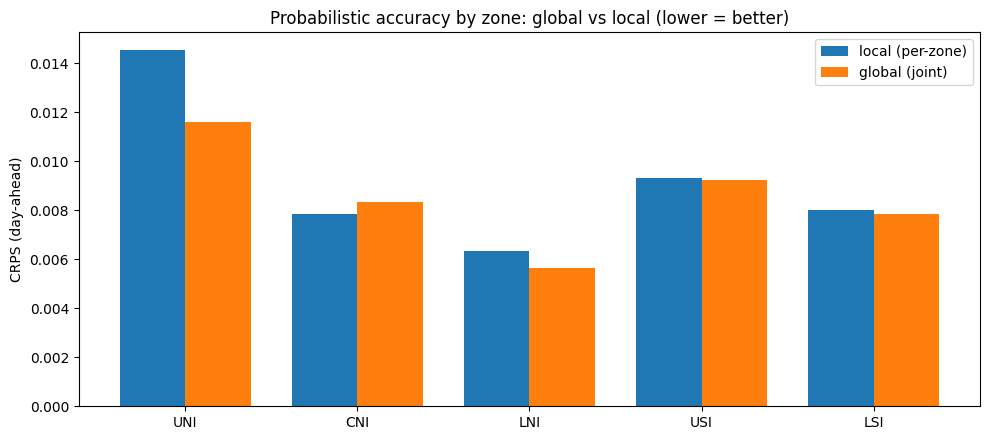

national P50-MAE (sum of zones):
  local: day-ahead 0.0349 | week 0.0514
  global: day-ahead 0.0385 | week 0.0570


In [5]:
# CRPS bar comparison (day-ahead)
d = cmp[cmp.horizon == fu.H_DAY]
x = np.arange(len(ZONES)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, d[d.model=="local"].set_index("zone").loc[ZONES, "CRPS"], w, label="local (per-zone)")
ax.bar(x + w/2, d[d.model=="global"].set_index("zone").loc[ZONES, "CRPS"], w, label="global (joint)")
ax.set_xticks(x); ax.set_xticklabels(ZONES); ax.set_ylabel("CRPS (day-ahead)")
ax.set_title("Probabilistic accuracy by zone: global vs local (lower = better)"); ax.legend()
plt.tight_layout(); plt.show()

print("national P50-MAE (sum of zones):")
for tag, store in [("local", local_btq), ("global", global_btq)]:
    yt = sum(store[z]["y_true"] for z in ZONES)
    yp = sum(store[z]["y_q"][:, I50, :] for z in ZONES)
    print(f"  {tag}: day-ahead {fu.mae(yt[:, :fu.H_DAY].ravel(), yp[:, :fu.H_DAY].ravel()):.4f}"
          f" | week {fu.mae(yt.ravel(), yp.ravel()):.4f}")

## 4. Calibrate the global model's intervals with CQR

Raw neural-network quantiles often **under-cover** out-of-sample. Apply **CQR** per zone to the global model: estimate the conformity score `E = max(P10-y, y-P90)` on the validation set and widen the test-period intervals by its quantile so coverage approaches the nominal 80%.

In [6]:
def val_quantiles(model, zz):
    Xp, Xf, Yv = deep.make_windows(zz["ys"], zz["Xoh"], starts[-nv:], L, H)
    model.eval()
    with torch.no_grad():
        q = np.sort(model(Xp.to(DEV), Xf.to(DEV)).cpu().numpy(), axis=1) * zz["ysd"] + zz["ymu"]
    return q, Yv.numpy() * zz["ysd"] + zz["ymu"]

cqr_rows = []
global_cqr = {}
n = len(starts[-nv:])
level = min(1.0, (1 - ALPHA) * (1 + 1 / n))
for z in ZONES:
    vq, vt = val_quantiles(gmodel, Z[z])
    E = np.maximum(vq[:, I10, :] - vt, vt - vq[:, I90, :])
    q_cqr = np.quantile(E, level, axis=0)
    btq = global_btq[z]
    lo = btq["y_q"][:, I10, :] - q_cqr
    hi = btq["y_q"][:, I90, :] + q_cqr
    global_cqr[z] = (lo, hi)
    for h in HORIZONS:
        yt = btq["y_true"][:, :h]
        cqr_rows.append({"zone": z, "horizon": h,
                         "cover_raw": fu.coverage(yt, btq["y_q"][:, I10, :h], btq["y_q"][:, I90, :h]),
                         "cover_CQR": fu.coverage(yt, lo[:, :h], hi[:, :h]),
                         "width_CQR": fu.interval_width(lo[:, :h], hi[:, :h])})
cqr = pd.DataFrame(cqr_rows)
print("global model 80% interval coverage: raw vs CQR-calibrated")
display(cqr.round(3))

global model 80% interval coverage: raw vs CQR-calibrated


,zone,horizon,cover_raw,cover_CQR,width_CQR
0,UNI,48,0.723,0.711,0.045
1,UNI,336,0.636,0.691,0.058
2,CNI,48,0.719,0.747,0.032
3,CNI,336,0.617,0.738,0.043
4,LNI,48,0.785,0.769,0.022
5,LNI,336,0.672,0.706,0.028
6,USI,48,0.656,0.735,0.033
7,USI,336,0.522,0.697,0.047
8,LSI,48,0.551,0.781,0.027
9,LSI,336,0.512,0.861,0.042


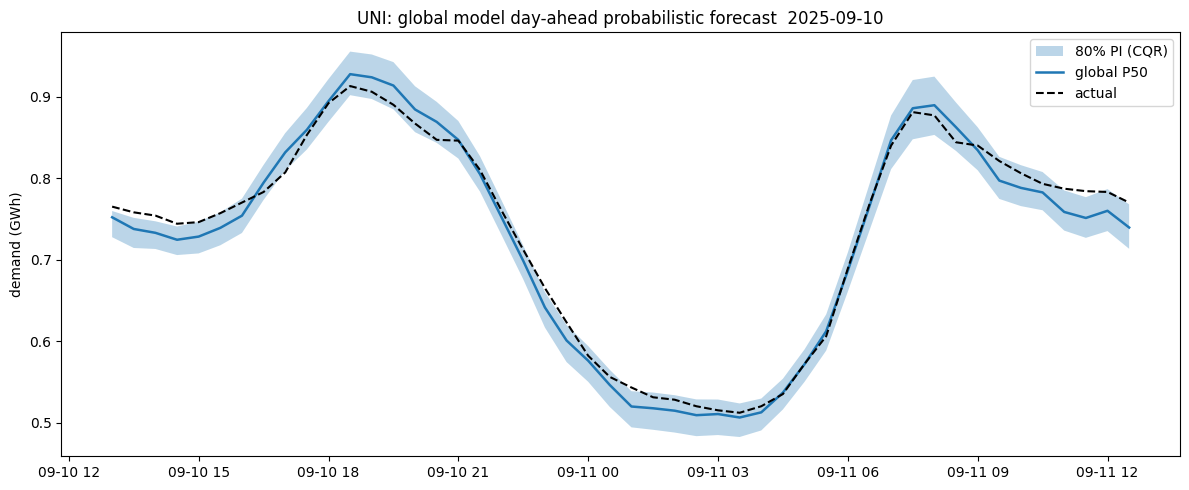

In [7]:
# fan chart: global model CQR interval (one zone/origin, day-ahead)
z = "UNI"; o = origins[len(origins)//2]; i = origins.index(o); h = fu.H_DAY
idx = common[o + 1: o + 1 + h].tz_convert(fu.TZ)
lo, hi = global_cqr[z]
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(idx, lo[i, :h], hi[i, :h], alpha=0.3, label="80% PI (CQR)")
ax.plot(idx, global_btq[z]["y_q"][i, I50, :h], lw=1.8, label="global P50")
ax.plot(idx, global_btq[z]["y_true"][i, :h], "k--", lw=1.5, label="actual")
ax.set_title(f"{z}: global model day-ahead probabilistic forecast  {idx[0]:%Y-%m-%d}")
ax.set_ylabel("demand (GWh)"); ax.legend(); plt.tight_layout(); plt.show()

In [8]:
# Save comparison scores
out = cmp.assign(scope="global_vs_local")
out.to_csv(ROOT / "data" / "processed" / "scores_global_local.csv", index=False)
cqr.to_csv(ROOT / "data" / "processed" / "scores_cqr_global.csv", index=False)
print("saved scores_global_local.csv, scores_cqr_global.csv")
cmp[cmp.horizon == fu.H_DAY].pivot(index="zone", columns="model", values=["CRPS", "P50_MAE"]).round(4)

saved scores_global_local.csv, scores_cqr_global.csv


CRPS         P50_MAE        
model  global   local  global   local
zone                                 
CNI    0.0083  0.0079  0.0110  0.0104
LNI    0.0056  0.0063  0.0075  0.0081
LSI    0.0078  0.0080  0.0097  0.0102
UNI    0.0116  0.0145  0.0151  0.0182
USI    0.0092  0.0093  0.0118  0.0118

---
### Summary
- **Global joint vs per-zone local**: a single global TiDE with a zone one-hot sees 5x more data and usually has **lower or comparable CRPS and point error in most zones** — deep models benefit from data volume in particular; and it needs only **1 model** instead of 5, which is cheaper to maintain.
- **CRPS** gives a combined point+interval probabilistic score (lower is better), more complete than coverage alone.
- **CQR** calibrates the global model's out-of-sample under-covering intervals back toward the nominal 80%; long horizons still fall short due to distribution shift.

Next: add richer zone static features to the global model (lat/lon/population/big-industrial loads such as Tiwai); per-zone CQR is done, online rolling calibration could be added; operational interval forecasting driven by real forecast weather.